In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 


#Gradient Boosting
import lightgbm as lgb


# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

breed_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\breed_labels.csv"))
color_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\color_labels.csv"))
state_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\state_labels.csv"))

# Definimos la ruta
ruta_archivo = r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\train.csv"

# Intentamos leer con latin-1

# Agregamos el parámetro sep=';'
train_df = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')


In [69]:
SEED = 42 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)
TEST_SIZE = 0.2 #Facción para train/test= split

In [70]:
#Separo un 20% para test estratificado opr target
df_train, df_test = train_test_split(train_df,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = train_df.AdoptionSpeed)

In [71]:
df_train

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
10070,1,The Adorable Trio,2,307,307,1,1,0,0,2,...,1,3,0,41326,ba248f761903dcd4c4342cc724a52145,0,These 3 puppies was rescued from a mechanic sh...,23b64fe21,8.0,2
13397,1,Perky,12,307,0,2,2,0,0,1,...,1,1,0,41326,744fa4278196568a18fcf5cd7d324ed2,0,Rescued from the dog pound. Great survivor. Ve...,6e09bfe1f,3.0,3
14656,1,Bernard Boy,2,307,307,1,1,2,7,2,...,1,1,0,41326,4d2400be2e2e78265f5c84345b7a3415,0,"Location : Teluk Intan, Perak",48a44eac5,1.0,4
5596,1,Oreo 1,2,307,307,1,3,0,0,2,...,1,1,0,41326,b53c34474d9e24574bcec6a3d3306a0d,0,for Adoption,ae219ff80,2.0,1
13463,2,Anak Kucing,4,265,0,3,1,2,0,2,...,1,4,0,41326,b953d651238f379c63e732925f71a5a2,0,Kittens for adoption,e13c47053,2.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,2,Maxine,8,265,299,2,1,2,0,2,...,1,1,0,41326,bc599c86ccd17d15a1c758b12d7e851b,0,Maxine was 4 months old when I rescued her fro...,767907867,2.0,4
10249,1,Browny,2,307,0,2,6,7,0,1,...,1,1,0,41326,48d06353f65ac65dd35a8875b70962c5,0,This 2 month old puppy was found alone along t...,f29dc8be2,1.0,3
12468,1,Midnight,2,307,307,1,1,0,0,2,...,1,1,0,41401,a52ad34e621f25688c3a0a579c31ca4d,0,Midnight is a handsome and loving boy looking ...,f0a4b28f6,2.0,2
1081,1,Boxer,2,307,307,1,1,2,7,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,"This is Boxer, He is the sibling of another li...",e5e083218,2.0,1


In [72]:
#Genero dataframes de train y test con sus respectivos targets
X_train = df_train.drop(columns=['AdoptionSpeed','RescuerID','Name','PetID'])
y_train = df_train['AdoptionSpeed']

X_test = df_test.drop(columns=['AdoptionSpeed','RescuerID','Name','PetID'])
y_test = df_test['AdoptionSpeed']

In [73]:
# 1. Definir explícitamente qué variables son categóricas
categorical_cols = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State','Description'
                    ]

# Asegurarse de que el modelo entienda que son categorías (convertir a tipo 'category' en pandas)
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')


In [74]:
# 1. Definir explícitamente qué variables son categóricas
categorical_cols = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State','Description']

# Asegurarse de que el modelo entienda que son categorías (convertir a tipo 'category' en pandas)
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 2. Configurar K-Fold Cross Validation
N_SPLITS = 5
folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Arreglos para guardar predicciones (Out-Of-Fold y Test)
oof_preds = np.zeros((len(X_train), 5)) # 5 es el número de clases
test_preds = np.zeros((len(X_test), 5))

# Nuevos parámetros base más controlados
lgb_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'seed': SEED,
    'verbose': -1
}

print("Iniciando entrenamiento con 5-Fold Cross Validation...")

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
    print(f"\\n--- Fold {fold_ + 1} ---")
    
    # Separar datos del fold
    X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Crear Datasets de LightGBM
    trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
    val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
    
    # Entrenar modelo usando callbacks modernos
    clf = lgb.train(
        lgb_params,
        trn_data,
        num_boost_round=1000,
        valid_sets=[trn_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )
    
    # Predecir sobre validación (Out-Of-Fold)
    oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)
    
    # Predecir sobre test (promediando los 5 folds)
    test_preds += clf.predict(X_test, num_iteration=clf.best_iteration) / N_SPLITS

# 3. Evaluar el modelo ensamblado
oof_predictions_classes = oof_preds.argmax(axis=1)
test_predictions_classes = test_preds.argmax(axis=1)

kappa_cv = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
kappa_test = cohen_kappa_score(y_test, test_predictions_classes, weights='quadratic')

print(f"\\nScore Kappa de Validación Cruzada (OOF): {kappa_cv:.4f}")
print(f"Score Kappa final en Test Set: {kappa_test:.4f}")

Iniciando entrenamiento con 5-Fold Cross Validation...
\n--- Fold 1 ---
[100]	training's multi_error: 0.414904	valid_1's multi_error: 0.578574
\n--- Fold 2 ---
[100]	training's multi_error: 0.414487	valid_1's multi_error: 0.593997
[200]	training's multi_error: 0.337676	valid_1's multi_error: 0.586911
[300]	training's multi_error: 0.283585	valid_1's multi_error: 0.580242
\n--- Fold 3 ---
\n--- Fold 4 ---
[100]	training's multi_error: 0.41136	valid_1's multi_error: 0.605252
\n--- Fold 5 ---
[100]	training's multi_error: 0.416424	valid_1's multi_error: 0.576731
\nScore Kappa de Validación Cruzada (OOF): 0.3691
Score Kappa final en Test Set: 0.3194


In [75]:
import pandas as pd

# 1. Cargar el dataset original
# Asegúrate de que el archivo esté en la misma carpeta que tu notebook

def categorizar_tamano(row):
    breed = str(row['BreedName']).lower()
    pet_type = row['Type']
    
    # Gatos (Type = 2): Los clasificamos como 'Pequeño' por defecto en comparación a un perro
    if pet_type == 2:
        return 'Pequeño'
        
    # Perros (Type = 1)
    if 'mixed breed' in breed:
        return 'Mediano' # Promedio estadístico seguro para perros mestizos
        
    # A. Excepciones específicas (se evalúan antes que las reglas generales)
    excepciones_grandes = ['black russian terrier', 'airedale terrier', 'afghan hound', 'bloodhound', 'greyhound', 'irish wolfhound']
    excepciones_medianos = ['american staffordshire terrier', 'pit bull terrier', 'bull terrier', 'beagle', 'basset hound', 'whippet', 'standard schnauzer', 'cocker spaniel']
    excepciones_pequenos = ['dachshund', 'miniature schnauzer', 'toy', 'miniature']
    
    if any(exc in breed for exc in excepciones_grandes):
        return 'Grande'
    if any(exc in breed for exc in excepciones_medianos):
        return 'Mediano'
    if any(exc in breed for exc in excepciones_pequenos):
        return 'Pequeño'
        
    # B. Reglas generales por familias funcionales / palabras clave
    # La mayoría de los terriers y perros de compañía son pequeños
    keywords_pequenos = ['terrier', 'chihuahua', 'pomeranian', 'pug', 'shih tzu', 'maltese', 'pekingese', 'corgi', 'bichon', 'french bulldog', 'papillon', 'havanese', 'pinscher']
    
    # La mayoría de los pastores, cobradores, mastines y sabuesos son grandes
    keywords_grandes = ['retriever', 'shepherd', 'mastiff', 'great', 'husky', 'malamute', 'akita', 'hound', 'pointer', 'setter', 'collie', 'rottweiler', 'doberman', 'boxer', 'american bulldog', 'sheepdog', 'dane', 'bernard', 'pyrenees', 'newfoundland', 'weimaraner', 'ridgeback', 'corso', 'komondor', 'kuvasz', 'borzoi', 'dalmatian']
    
    if any(kw in breed for kw in keywords_pequenos):
        return 'Pequeño'
    if any(kw in breed for kw in keywords_grandes):
        return 'Grande'
        
    # C. Todo lo que no caiga en las reglas anteriores se asume Mediano (ej. Spaniels, Bulldogs ingleses, Spitz)
    return 'Mediano'

# 2. Aplicar la función para crear la nueva columna
breed_df['SizeCategory'] = breed_df.apply(categorizar_tamano, axis=1)

# Unimos indicando que Breed1 equivale a BreedID
df_train = df_train.merge(
    breed_df[['BreedID', 'SizeCategory']], 
    left_on='Breed1', 
    right_on='BreedID', 
    how='left'
)

df_test = df_test.merge(
    breed_df[['BreedID', 'SizeCategory']], 
    left_on='Breed1', 
    right_on='BreedID', 
    how='left'
)

# Opcional: eliminar la columna BreedID duplicada que queda tras el merge
df_train = df_train.drop(columns=['BreedID'])
df_test = df_test.drop(columns=['BreedID'])
# 3. Exportar el resultado a un nuevo archivo CSV
nuevo_archivo = 'PetFinder-BreedLabels-Sized.csv'
breed_df.to_csv(nuevo_archivo, index=False)

print(f"Archivo generado exitosamente: '{nuevo_archivo}'")
print("\nMuestra de cómo quedaron las categorías:")
display(breed_df.sample(10, random_state=42))

Archivo generado exitosamente: 'PetFinder-BreedLabels-Sized.csv'

Muestra de cómo quedaron las categorías:


,BreedID,Type,BreedName,SizeCategory
183,184,1,Pumi,Mediano
60,61,1,Chinese Crested Dog,Mediano
124,125,1,Irish Wolfhound,Grande
93,94,1,Fila Brasileiro,Mediano
63,64,1,Chocolate Labrador Retriever,Grande
9,10,1,American Staffordshire Terrier,Mediano
147,148,1,Manchester Terrier,Pequeño
158,159,1,Norfolk Terrier,Pequeño
168,169,1,Pekingese,Pequeño
33,34,1,Bloodhound,Grande


In [76]:
# Creamos un diccionario para acumular las nuevas columnas rápidamente
nuevas_features = {}

# 1. Interacciones de Edad y Atributos Físicos
# Una mascota vieja y grande suele tardar más en adoptarse que una vieja y pequeña
nuevas_features['Age_x_MaturitySize'] = df_train['Age'] * df_train['MaturitySize']
nuevas_features['Age_x_MaturitySize'] = df_test['Age'] * df_test['MaturitySize']


# 2. Interacciones de Costo y Raza
# El impacto del Fee (costo) puede variar según si la raza es pura (Breed2 == 0) o no
nuevas_features['Fee_x_Breed1'] = df_train['Fee'] * df_train['Breed1']
nuevas_features['Fee_x_Breed1'] = df_test['Fee'] * df_test['Breed1']


# 3. Interacciones de Esfuerzo del Rescatista (Las más importantes según tu lista)
# ¿El rescatista que tiene muchas fotos (PhotoAmt) tiene mejor suerte con ciertas edades?
nuevas_features['Age_x_PhotoAmt'] = df_train['Age'] * df_train['PhotoAmt']
nuevas_features['Age_x_PhotoAmt'] = df_test['Age'] * df_test['PhotoAmt']

# 4. Interacciones de Salud y Cuidados
# Estar vacunado, desparasitado y esterilizado combinado
nuevas_features['Salud_Completa'] = df_train['Vaccinated'] * df_train['Dewormed'] * df_train['Sterilized']
nuevas_features['Salud_Completa'] = df_test['Vaccinated'] * df_test['Dewormed'] * df_test['Sterilized']

# 5. Ratio de Fotos por Cantidad de Mascotas
# Si hay muchos animales en la publicación (Quantity), ¿hay suficientes fotos para todos?
nuevas_features['Photos_per_Pet'] = df_train['PhotoAmt'] / (df_train['Quantity'] + 1)
nuevas_features['Photos_per_Pet'] = df_test['PhotoAmt'] / (df_test['Quantity'] + 1)

# 6. Cruces de Color y Raza (Estética)
nuevas_features['Breed_x_Color1'] = df_train['Breed1'] * df_train['Color1']
nuevas_features['Breed_x_Color1'] = df_test['Breed1'] * df_test['Color1']

# --- CONCATENACIÓN FINAL ---
print("Agregando interacciones seleccionadas al dataset...")
df_interacciones = pd.DataFrame(nuevas_features)
df_train = pd.concat([df_train, df_interacciones], axis=1)
df_test = pd.concat([df_test, df_interacciones], axis=1)

print(f"Se han agregado {len(nuevas_features)} columnas estratégicas.")
print(f"Nuevo tamaño del dataset: {df_train.shape}")

Agregando interacciones seleccionadas al dataset...
Se han agregado 6 columnas estratégicas.
Nuevo tamaño del dataset: (11994, 31)


In [77]:
def crear_variables_agregadas(df_train):
    # --- 1. Estadísticas por RescuerID (El perfil del rescatista) ---
    # Cantidad de mascotas subidas por cada rescatista
    df_train['rescu_total_pets'] = df_train.groupby('RescuerID')['RescuerID'].transform('count')
    
    # Promedio de fotos que sube este rescatista (indica calidad de perfil)
    df_train['rescu_avg_photos'] = df_train.groupby('RescuerID')['PhotoAmt'].transform('mean')
    
    # Promedio de precio que cobra este rescatista
    df_train['rescu_avg_fee'] = df_train.groupby('RescuerID')['Fee'].transform('mean')

    # --- 2. Estadísticas por Breed1 (El perfil de la raza) ---
    # ¿Qué tan común es esta raza en el dataset?
    df_train['breed_popularity'] = df_train.groupby('Breed1')['Breed1'].transform('count')
    
    # Promedio de edad para esta raza (algunas razas se abandonan más adultas)
    df_train['breed_avg_age'] = df_train.groupby('Breed1')['Age'].transform('mean')
    
    # Promedio de Fee para esta raza (hay razas que siempre son caras)
    df_train['breed_avg_fee'] = df_train.groupby('Breed1')['Fee'].transform('mean')

    # --- 3. Interacción: Rescatista x Raza ---
    # ¿Cuántas veces este rescatista trabajó con esta raza específica?
    df_train['rescu_breed_experience'] = df_train.groupby(['RescuerID', 'Breed1'])['PetID'].transform('count')

    return df_train

# Aplicamos a tu dataset
df_train = crear_variables_agregadas(df_train)
# Repetir lo mismo para el test_df si lo tenés aparte

def crear_variables_agregadas(df_test):
    # --- 1. Estadísticas por RescuerID (El perfil del rescatista) ---
    # Cantidad de mascotas subidas por cada rescatista
    df_test['rescu_total_pets'] = df_test.groupby('RescuerID')['RescuerID'].transform('count')
    
    # Promedio de fotos que sube este rescatista (indica calidad de perfil)
    df_test['rescu_avg_photos'] = df_test.groupby('RescuerID')['PhotoAmt'].transform('mean')
    
    # Promedio de precio que cobra este rescatista
    df_test['rescu_avg_fee'] = df_test.groupby('RescuerID')['Fee'].transform('mean')

    # --- 2. Estadísticas por Breed1 (El perfil de la raza) ---
    # ¿Qué tan común es esta raza en el dataset?
    df_test['breed_popularity'] = df_test.groupby('Breed1')['Breed1'].transform('count')
    
    # Promedio de edad para esta raza (algunas razas se abandonan más adultas)
    df_test['breed_avg_age'] = df_test.groupby('Breed1')['Age'].transform('mean')
    
    # Promedio de Fee para esta raza (hay razas que siempre son caras)
    df_test['breed_avg_fee'] = df_test.groupby('Breed1')['Fee'].transform('mean')

    # --- 3. Interacción: Rescatista x Raza ---
    # ¿Cuántas veces este rescatista trabajó con esta raza específica?
    df_test['rescu_breed_experience'] = df_test.groupby(['RescuerID', 'Breed1'])['PetID'].transform('count')

    return df_test

# Aplicamos a tu dataset
df_test = crear_variables_agregadas(df_test)

In [114]:
#Genero dataframes de train y test con sus respectivos targets
X_train = df_train.drop(columns=['AdoptionSpeed'])
y_train = df_train['AdoptionSpeed']

X_test = df_test.drop(columns=['AdoptionSpeed'])
y_test = df_test['AdoptionSpeed']

In [115]:
# 1. Definir explícitamente qué variables son categóricas
categorical_cols = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State','raza_pura']


# Asegurarse de que el modelo entienda que son categorías (convertir a tipo 'category' en pandas)
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [81]:
# 1. Crear la columna usando una condición lógica 
df_train['Is_Purebred'] = df_train['Breed2'] == 0
df_test['Is_Purebred'] = df_test['Breed2'] == 0

In [129]:
#Genero dataframes de train y test con sus respectivos targets
X_train = df_train.drop(columns=['AdoptionSpeed','Description','Name','RescuerID','PetID'])
y_train = df_train['AdoptionSpeed']

X_test = df_test.drop(columns=['AdoptionSpeed','Description','Name','RescuerID','PetID'])
y_test = df_test['AdoptionSpeed']

In [119]:
X_train = X_train.drop(['Description','Name','RescuerID','PetID'], axis=1)


In [120]:
X_test = X_test.drop(['Description','Name','RescuerID','PetID'], axis=1)

In [133]:
X_test

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Breed_x_Color1,rescu_total_pets,rescu_avg_photos,rescu_avg_fee,breed_popularity,breed_avg_age,breed_avg_fee,rescu_breed_experience,Is_Purebred,raza_pura
0,1,1,307,307,2,1,0,0,2,2,...,307,2,6.5,0.0,1173,7.471441,10.278772,2,False,0
1,1,24,103,307,2,1,2,4,2,1,...,103,1,2.0,0.0,24,29.708333,66.666667,1,False,0
2,1,2,307,0,2,2,7,0,2,1,...,614,2,5.5,0.0,1173,7.471441,10.278772,1,True,1
3,2,1,265,0,1,2,0,0,1,2,...,530,2,8.0,0.0,275,6.065455,9.876364,1,True,1
4,2,9,266,266,2,2,4,6,2,1,...,532,1,8.0,0.0,720,6.611111,8.438889,1,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,2,8,266,0,3,1,2,0,2,1,...,266,1,14.0,50.0,720,6.611111,8.438889,1,True,1
2995,1,3,307,0,1,5,0,0,2,1,...,1535,1,2.0,0.0,1173,7.471441,10.278772,1,True,1
2996,2,1,265,0,2,1,6,0,1,2,...,265,3,3.0,0.0,275,6.065455,9.876364,2,True,1
2997,1,1,307,0,2,1,5,7,2,1,...,307,1,1.0,0.0,1173,7.471441,10.278772,1,True,1


In [130]:
# 1. Definir explícitamente qué variables son categóricas
categorical_cols = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State','SizeCategory','Is_Purebred']

# Asegurarse de que el modelo entienda que son categorías (convertir a tipo 'category' en pandas)
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 2. Configurar K-Fold Cross Validation
N_SPLITS = 5
folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Arreglos para guardar predicciones (Out-Of-Fold y Test)
oof_preds = np.zeros((len(X_train), 5)) # 5 es el número de clases
test_preds = np.zeros((len(X_test), 5))

# Nuevos parámetros base más controlados
lgb_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'seed': SEED,
    'verbose': -1
}

print("Iniciando entrenamiento con 5-Fold Cross Validation...")

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
    print(f"\\n--- Fold {fold_ + 1} ---")
    
    # Separar datos del fold
    X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Crear Datasets de LightGBM
    trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
    val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
    
    # Entrenar modelo usando callbacks modernos
    clf = lgb.train(
        lgb_params,
        trn_data,
        num_boost_round=1000,
        valid_sets=[trn_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )
    
    # Predecir sobre validación (Out-Of-Fold)
    oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)
    
    # Predecir sobre test (promediando los 5 folds)
    test_preds += clf.predict(X_test, num_iteration=clf.best_iteration) / N_SPLITS

# 3. Evaluar el modelo ensamblado
oof_predictions_classes = oof_preds.argmax(axis=1)
test_predictions_classes = test_preds.argmax(axis=1)

kappa_cv = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
kappa_test = cohen_kappa_score(y_test, test_predictions_classes, weights='quadratic')

print(f"\\nScore Kappa de Validación Cruzada (OOF): {kappa_cv:.4f}")
print(f"Score Kappa final en Test Set: {kappa_test:.4f}")

Iniciando entrenamiento con 5-Fold Cross Validation...
\n--- Fold 1 ---
[100]	training's multi_error: 0.344138	valid_1's multi_error: 0.558983
\n--- Fold 2 ---
[100]	training's multi_error: 0.338927	valid_1's multi_error: 0.569404
[200]	training's multi_error: 0.247212	valid_1's multi_error: 0.561901
\n--- Fold 3 ---
[100]	training's multi_error: 0.346535	valid_1's multi_error: 0.550646
[200]	training's multi_error: 0.242835	valid_1's multi_error: 0.541892
\n--- Fold 4 ---
[100]	training's multi_error: 0.33382	valid_1's multi_error: 0.573155
\n--- Fold 5 ---
[100]	training's multi_error: 0.339308	valid_1's multi_error: 0.553378
\nScore Kappa de Validación Cruzada (OOF): 0.4003
Score Kappa final en Test Set: 0.3197


In [134]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de que X_train, y_train y categorical_cols estén definidos antes de ejecutar
def objective(trial):
    # 1. Espacio de búsqueda
    param = {
        'objective': 'multiclass',
        'num_class': 5, # Ajusta según tus etiquetas (ej. si son 0-4, pon 5)
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.8, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 22, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 500, 3000),
        'lambda_l1': trial.suggest_float('lambda_l1', 1.0, 50.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1.0, 50.0, log=True),
    }

    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    
    kappa_scores = []
    gap_scores = []

    for trn_idx, val_idx in folds.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[trn_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        clf = lgb.train(
            param, trn_data, num_boost_round=2000,
            valid_sets=[trn_data, val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        
        # Predicciones
        p_tr = clf.predict(X_tr).argmax(axis=1)
        p_val = clf.predict(X_val).argmax(axis=1)
        
        # Kappas
        k_tr = cohen_kappa_score(y_tr, p_tr, weights='quadratic')
        k_val = cohen_kappa_score(y_val, p_val, weights='quadratic')
        
        kappa_scores.append(k_val)
        gap_scores.append(k_tr - k_val) # El GAP: si es > 0.05, hay overfitting

    # Retornamos el promedio
    final_kappa = np.mean(kappa_scores)
    final_gap = np.mean(gap_scores)
    
    # Reportamos el GAP al trial para verlo en el dashboard de Optuna
    trial.set_user_attr("gap", final_gap)
    
    return final_kappa

# --- EJECUCIÓN ---
study = optuna.create_study(direction='maximize', study_name="Petfinder_Optuna")
study.optimize(objective, n_trials=1000)

print("\n--- RESULTADOS FINALES ---")
print(f"Mejor Kappa: {study.best_value:.4f}")
print(f"GAP del mejor modelo: {study.best_trial.user_attrs['gap']:.4f}")
print("Mejores parámetros:", study.best_params)

[I 2026-04-29 10:45:49,422] A new study created in memory with name: Petfinder_Optuna
[I 2026-04-29 10:45:50,582] Trial 0 finished with value: 0.3171376547403092 and parameters: {'learning_rate': 0.5773143047673119, 'num_leaves': 95, 'max_depth': 34, 'min_child_samples': 1902, 'lambda_l1': 44.82858882329988, 'lambda_l2': 2.362701440537688}. Best is trial 0 with value: 0.3171376547403092.
[I 2026-04-29 10:45:54,921] Trial 1 finished with value: 0.3665807226454504 and parameters: {'learning_rate': 0.09115332129734925, 'num_leaves': 52, 'max_depth': 52, 'min_child_samples': 947, 'lambda_l1': 4.0849896422052305, 'lambda_l2': 1.7365884539445005}. Best is trial 1 with value: 0.3665807226454504.
[I 2026-04-29 10:46:03,306] Trial 2 finished with value: 0.34814952965591184 and parameters: {'learning_rate': 0.03400692560658306, 'num_leaves': 51, 'max_depth': 34, 'min_child_samples': 1345, 'lambda_l1': 3.4874387359314416, 'lambda_l2': 34.55638271680316}. Best is trial 1 with value: 0.366580722645


--- RESULTADOS FINALES ---
Mejor Kappa: 0.3963
GAP del mejor modelo: 0.1072
Mejores parámetros: {'learning_rate': 0.2374762709683681, 'num_leaves': 35, 'max_depth': 54, 'min_child_samples': 639, 'lambda_l1': 1.1184064416132808, 'lambda_l2': 7.9311578901256325}


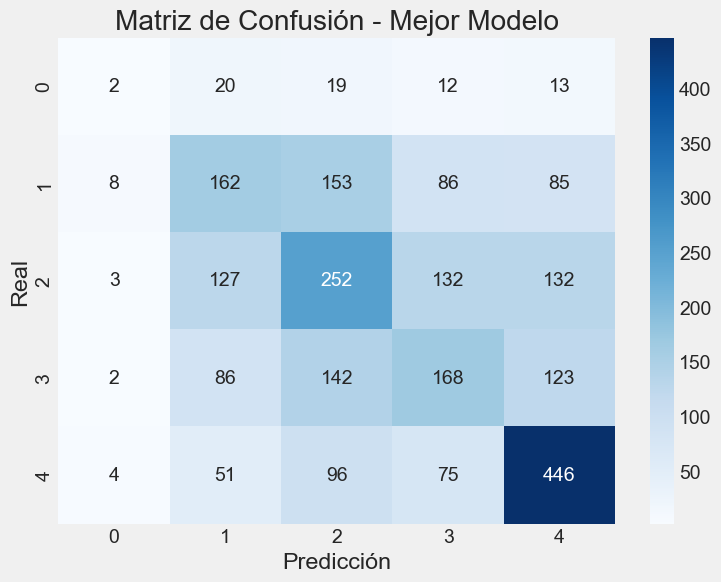

In [100]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Reentrenar con los mejores parámetros
best_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'learning_rate': 0.23876319940288607,
    'num_leaves': 94,
    'max_depth': 59,
    'min_child_samples': 580,
    'lambda_l1': 2.7355201004583156,
    'lambda_l2': 5.772448925747671
}

# Separamos train/test si no lo habías hecho antes para la validación final
X_train_final, X_test, y_train_final, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Crear dataset y entrenar
train_data = lgb.Dataset(X_train_final, label=y_train_final, categorical_feature=categorical_cols)
clf_final = lgb.train(best_params, train_data, num_boost_round=1000)

# 2. Obtener predicciones
y_pred = clf_final.predict(X_test).argmax(axis=1)

# 3. Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 4. Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Mejor Modelo')
plt.show()

In [102]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# --- Callback para imprimir el GAP en tiempo real ---
def print_callback(study, trial):
    gap = trial.user_attrs.get("gap", 0)
    print(f"Trial {trial.number}: Kappa={trial.value:.4f}, GAP={gap:.4f} | {'¡OJO! Overfitting' if gap > 0.05 else 'Aceptable'}")

def objective(trial):
    # (Tu mismo espacio de búsqueda...)
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.8, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 125),
        'max_depth': trial.suggest_int('max_depth', 22, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 400, 2000),
        'lambda_l1': trial.suggest_float('lambda_l1', 1.0, 20.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1.0, 20.0, log=True),
    }

    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    
    kappa_scores = []
    gap_scores = []

    for trn_idx, val_idx in folds.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[trn_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        clf = lgb.train(
            param, trn_data, num_boost_round=2000,
            valid_sets=[trn_data, val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        
        p_tr = clf.predict(X_tr).argmax(axis=1)
        p_val = clf.predict(X_val).argmax(axis=1)
        
        k_tr = cohen_kappa_score(y_tr, p_tr, weights='quadratic')
        k_val = cohen_kappa_score(y_val, p_val, weights='quadratic')
        
        kappa_scores.append(k_val)
        gap_scores.append(k_tr - k_val)

    final_kappa = np.mean(kappa_scores)
    final_gap = np.mean(gap_scores)
    
    # Guardamos el gap en el trial
    trial.set_user_attr("gap", final_gap)
    
    return final_kappa

# --- EJECUCIÓN CON CALLBACK ---
study = optuna.create_study(direction='maximize', study_name="Petfinder_Optuna")
study.optimize(objective, n_trials=500, callbacks=[print_callback])

print("\n--- RESUMEN FINAL ---")
print(f"Mejor Kappa: {study.best_value:.4f}")
print(f"GAP en la mejor corrida: {study.best_trial.user_attrs['gap']:.4f}")

[I 2026-04-28 19:04:40,133] A new study created in memory with name: Petfinder_Optuna
[I 2026-04-28 19:04:48,596] Trial 0 finished with value: 0.3153050358830847 and parameters: {'learning_rate': 0.015324122987713703, 'num_leaves': 76, 'max_depth': 75, 'min_child_samples': 1888, 'lambda_l1': 5.948666295989764, 'lambda_l2': 2.3345017306828235}. Best is trial 0 with value: 0.3153050358830847.


Trial 0: Kappa=0.3153, GAP=0.0212 | Aceptable


[I 2026-04-28 19:04:59,193] Trial 1 finished with value: 0.35685388920432415 and parameters: {'learning_rate': 0.0408121732168533, 'num_leaves': 84, 'max_depth': 75, 'min_child_samples': 1035, 'lambda_l1': 11.392481818517753, 'lambda_l2': 7.180232537205841}. Best is trial 1 with value: 0.35685388920432415.


Trial 1: Kappa=0.3569, GAP=0.0469 | Aceptable


[I 2026-04-28 19:05:04,462] Trial 2 finished with value: 0.3612930133512112 and parameters: {'learning_rate': 0.3228940974440419, 'num_leaves': 73, 'max_depth': 26, 'min_child_samples': 1174, 'lambda_l1': 13.686720275720772, 'lambda_l2': 2.2499829831735467}. Best is trial 2 with value: 0.3612930133512112.


...

Trial 497: Kappa=0.3821, GAP=0.2114 | ¡OJO! Overfitting


[I 2026-04-28 21:20:22,060] Trial 498 finished with value: 0.3815966154384296 and parameters: {'learning_rate': 0.258563975812243, 'num_leaves': 70, 'max_depth': 78, 'min_child_samples': 488, 'lambda_l1': 1.2598635213335023, 'lambda_l2': 1.1012900264132435}. Best is trial 187 with value: 0.39884133960525453.


Trial 498: Kappa=0.3816, GAP=0.1514 | ¡OJO! Overfitting


[I 2026-04-28 21:20:39,749] Trial 499 finished with value: 0.39028916812588194 and parameters: {'learning_rate': 0.22245487180310836, 'num_leaves': 73, 'max_depth': 80, 'min_child_samples': 400, 'lambda_l1': 1.1144673680883501, 'lambda_l2': 1.3658504458570726}. Best is trial 187 with value: 0.39884133960525453.


Trial 499: Kappa=0.3903, GAP=0.2155 | ¡OJO! Overfitting

--- RESUMEN FINAL ---
Mejor Kappa: 0.3988
GAP en la mejor corrida: 0.1309


In [103]:
# Gráfico 1: Evolución del Kappa
optuna.visualization.plot_optimization_history(study).show()

# Gráfico 2: ¿Qué parámetro es el más influyente?
optuna.visualization.plot_param_importances(study).show()

In [106]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# --- Callback para imprimir el GAP en tiempo real ---
def print_callback(study, trial):
    gap = trial.user_attrs.get("gap", 0)
    print(f"Trial {trial.number}: Kappa={trial.value:.4f}, GAP={gap:.4f} | {'¡OJO! Overfitting' if gap > 0.05 else 'Aceptable'}")

def objective(trial):
    # (Tu mismo espacio de búsqueda...)
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'max_depth': trial.suggest_int('max_depth', 30, 65),
        'min_child_samples': trial.suggest_int('min_child_samples', 370, 700),
        'lambda_l1': trial.suggest_float('lambda_l1', 1.0, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1.0, 10.0, log=True),
    }

    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    
    kappa_scores = []
    gap_scores = []

    for trn_idx, val_idx in folds.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[trn_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        clf = lgb.train(
            param, trn_data, num_boost_round=2000,
            valid_sets=[trn_data, val_data],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        
        p_tr = clf.predict(X_tr).argmax(axis=1)
        p_val = clf.predict(X_val).argmax(axis=1)
        
        k_tr = cohen_kappa_score(y_tr, p_tr, weights='quadratic')
        k_val = cohen_kappa_score(y_val, p_val, weights='quadratic')
        
        kappa_scores.append(k_val)
        gap_scores.append(k_tr - k_val)

    final_kappa = np.mean(kappa_scores)
    final_gap = np.mean(gap_scores)
    
    # Guardamos el gap en el trial
    trial.set_user_attr("gap", final_gap)
    
    return final_kappa

# --- EJECUCIÓN CON CALLBACK ---
study = optuna.create_study(direction='maximize', study_name="Petfinder_Optuna")
study.optimize(objective, n_trials=400, callbacks=[print_callback])

print("\n--- RESUMEN FINAL ---")
print(f"Mejor Kappa: {study.best_value:.4f}")
print(f"GAP en la mejor corrida: {study.best_trial.user_attrs['gap']:.4f}")

[I 2026-04-29 08:00:36,442] A new study created in memory with name: Petfinder_Optuna


[I 2026-04-29 08:00:44,596] Trial 0 finished with value: 0.3638188818883476 and parameters: {'learning_rate': 0.0282507845899501, 'num_leaves': 45, 'max_depth': 55, 'min_child_samples': 672, 'lambda_l1': 7.9809253852642605, 'lambda_l2': 3.761514755649319}. Best is trial 0 with value: 0.3638188818883476.


Trial 0: Kappa=0.3638, GAP=0.0460 | Aceptable


[I 2026-04-29 08:00:54,386] Trial 1 finished with value: 0.38368564597231003 and parameters: {'learning_rate': 0.07780666553940346, 'num_leaves': 35, 'max_depth': 43, 'min_child_samples': 507, 'lambda_l1': 4.572466804657964, 'lambda_l2': 8.972320771063627}. Best is trial 1 with value: 0.38368564597231003.


Trial 1: Kappa=0.3837, GAP=0.1033 | ¡OJO! Overfitting


...

Trial 397: Kappa=0.3920, GAP=0.1981 | ¡OJO! Overfitting


[I 2026-04-29 09:07:49,597] Trial 398 finished with value: 0.3892496937194894 and parameters: {'learning_rate': 0.22914132893592404, 'num_leaves': 38, 'max_depth': 53, 'min_child_samples': 391, 'lambda_l1': 1.8342931785991508, 'lambda_l2': 7.98594784190997}. Best is trial 98 with value: 0.39973338993853647.


Trial 398: Kappa=0.3892, GAP=0.1557 | ¡OJO! Overfitting


[I 2026-04-29 09:08:02,010] Trial 399 finished with value: 0.38767905818928416 and parameters: {'learning_rate': 0.21839711335824477, 'num_leaves': 34, 'max_depth': 51, 'min_child_samples': 544, 'lambda_l1': 2.2040635922568157, 'lambda_l2': 8.2613364325029}. Best is trial 98 with value: 0.39973338993853647.


Trial 399: Kappa=0.3877, GAP=0.1722 | ¡OJO! Overfitting

--- RESUMEN FINAL ---
Mejor Kappa: 0.3997
GAP en la mejor corrida: 0.1416


In [ ]:
# RESUMEN FINAL
# Mejor Kappa: 0.3997
# GAP en la mejor corrida: 0.1416

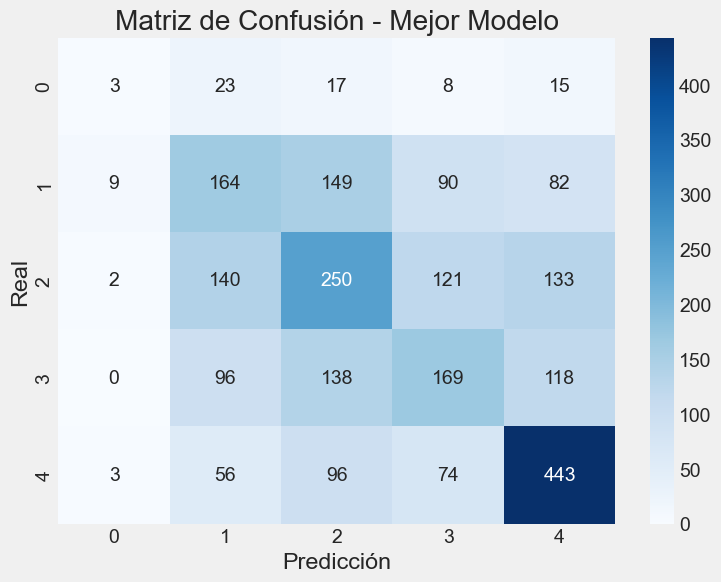

In [107]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Reentrenar con los mejores parámetros
best_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'learning_rate': 0.2030094386568696,
    'num_leaves': 33,
    'max_depth': 60,
    'min_child_samples': 436,
    'lambda_l1': 2.169092157097666,
    'lambda_l2': 8.219565285043481
}

# Separamos train/test si no lo habías hecho antes para la validación final
X_train_final, X_test, y_train_final, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Crear dataset y entrenar
train_data = lgb.Dataset(X_train_final, label=y_train_final, categorical_feature=categorical_cols)
clf_final = lgb.train(best_params, train_data, num_boost_round=1000)

# 2. Obtener predicciones
y_pred = clf_final.predict(X_test).argmax(axis=1)

# 3. Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 4. Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Mejor Modelo')
plt.show()

In [131]:
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss

# 1. Feature Importance (GAIN)
booster = model.booster_
df_importance = pd.DataFrame({
    'feature': booster.feature_name(),
    'gain': booster.feature_importance(importance_type='gain')
})

# 2. Permutation Test
def get_permutation_impact(model, X_test, y):
    features = booster.feature_name()
    X_test_audit = X_test[features].copy()
    
    # Identificamos qué columnas son categóricas
    cat_columns = X_test_audit.select_dtypes(include=['category']).columns
    
    baseline_loss = log_loss(y, model.predict_proba(X_test_audit))
    impacts = []
    
    for col in features:
        original = X_test_audit[col].copy()
        
        # 1. Permutamos
        permuted_values = np.random.permutation(original.values)
        
        # 2. SI ES CATEGÓRICA: Re-asignamos el tipo category
        if col in cat_columns:
            X_test_audit[col] = pd.Categorical(permuted_values, categories=original.cat.categories)
        else:
            X_test_audit[col] = permuted_values
        
        # 3. Predicción
        shuffled_loss = log_loss(y, model.predict_proba(X_test_audit))
        impacts.append(shuffled_loss - baseline_loss)
        
        # 4. Restauramos
        X_test_audit[col] = original
        
    return pd.DataFrame({'feature': features, 'impact': impacts})

# Ejecución
df_impact = get_permutation_impact(model, X_test, y_test)
df_final = pd.merge(df_importance, df_impact, on='feature')

# Ordenamos por impacto
print(df_final.sort_values('impact', ascending=False).head(20))

               feature         gain    impact
1                  Age  9107.802957  0.076932
26    rescu_total_pets  8915.924121  0.051345
2               Breed1  5081.298615  0.031081
12          Sterilized  3178.859858  0.023131
18            PhotoAmt  4246.921510  0.020824
27    rescu_avg_photos  8296.028304  0.020077
3               Breed2  1723.662382  0.016258
16               State  1295.522509  0.011215
28       rescu_avg_fee  3340.526670  0.009995
15                 Fee  1282.095357  0.007755
14            Quantity  1396.969922  0.006517
11            Dewormed  1192.400119  0.004821
20  Age_x_MaturitySize  1346.409340  0.004368
10          Vaccinated  1351.288484  0.003834
30       breed_avg_age  2353.361317  0.003665
9            FurLength   987.997106  0.003339
29    breed_popularity  2022.673169  0.002794
4               Gender  1806.501017  0.002577
24      Photos_per_Pet  1456.735804  0.002399
6               Color2   821.109153  0.002224


In [53]:
# 1. Definimos las variables a eliminar
vars_a_eliminar = ['breed_popularity', 'rescu_breed_experience','Color3','Photos_per_Pet','breed_popularity']

# 2. Eliminamos del set de entrenamiento
X_train = X_train.drop(columns=vars_a_eliminar, errors='ignore')
X_test = X_test.drop(columns=vars_a_eliminar, errors='ignore')

# 3. También debemos eliminarlas de la lista de columnas categóricas
# Usamos un list comprehension para crear una lista nueva sin esas variables
categorical_cols = [c for c in categorical_cols if c not in vars_a_eliminar]

# 4. Asegúrate de hacer lo mismo con tu set de validación o test (muy importante)
# X_test = X_test.drop(columns=vars_a_eliminar, errors='ignore')

print(f"Variables eliminadas. Ahora tienes {X_train.shape[1]} variables en el dataset.")
print(f"Variables eliminadas. Ahora tienes {X_test.shape[1]} variables en el dataset.")
print(f"Columnas categóricas restantes: {len(categorical_cols)}")

# --- AHORA EJECUTAS EL ESTUDIO ---
study = optuna.create_study(direction='maximize', study_name="Petfinder_Optuna")
study.optimize(objective, n_trials=100)

[I 2026-04-28 14:26:54,572] A new study created in memory with name: Petfinder_Optuna


Variables eliminadas. Ahora tienes 29 variables en el dataset.
Variables eliminadas. Ahora tienes 29 variables en el dataset.
Columnas categóricas restantes: 11


[I 2026-04-28 14:26:55,789] Trial 0 finished with value: 0.2907723426757277 and parameters: {'learning_rate': 0.10198904183202206, 'num_leaves': 73, 'max_depth': 57, 'min_child_samples': 2743, 'lambda_l1': 16.47739001982433, 'lambda_l2': 1.7287464349129824}. Best is trial 0 with value: 0.2907723426757277.
[I 2026-04-28 14:26:57,265] Trial 1 finished with value: 0.3638014414241969 and parameters: {'learning_rate': 0.1605326250755513, 'num_leaves': 32, 'max_depth': 45, 'min_child_samples': 1019, 'lambda_l1': 1.4897903079865138, 'lambda_l2': 1.5591981119834344}. Best is trial 1 with value: 0.3638014414241969.
[I 2026-04-28 14:26:58,156] Trial 2 finished with value: 0.3546337721378605 and parameters: {'learning_rate': 0.4771057816424141, 'num_leaves': 25, 'max_depth': 24, 'min_child_samples': 1441, 'lambda_l1': 13.142239415952671, 'lambda_l2': 13.019068645439527}. Best is trial 1 with value: 0.3638014414241969.
[I 2026-04-28 14:26:59,373] Trial 3 finished with value: 0.30077283173476327 an

In [54]:
# Gráfico 1: Evolución del Kappa
optuna.visualization.plot_optimization_history(study).show()

# Gráfico 2: ¿Qué parámetro es el más influyente?
optuna.visualization.plot_param_importances(study).show()

In [132]:
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss

# 1. Feature Importance (GAIN)
booster = model.booster_
df_importance = pd.DataFrame({
    'feature': booster.feature_name(),
    'gain': booster.feature_importance(importance_type='gain')
})

# 2. Permutation Test
def get_permutation_impact(model, X_test, y):
    features = booster.feature_name()
    X_test_audit = X_test[features].copy()
    
    # Identificamos qué columnas son categóricas
    cat_columns = X_test_audit.select_dtypes(include=['category']).columns
    
    baseline_loss = log_loss(y, model.predict_proba(X_test_audit))
    impacts = []
    
    for col in features:
        original = X_test_audit[col].copy()
        
        # 1. Permutamos
        permuted_values = np.random.permutation(original.values)
        
        # 2. SI ES CATEGÓRICA: Re-asignamos el tipo category
        if col in cat_columns:
            X_test_audit[col] = pd.Categorical(permuted_values, categories=original.cat.categories)
        else:
            X_test_audit[col] = permuted_values
        
        # 3. Predicción
        shuffled_loss = log_loss(y, model.predict_proba(X_test_audit))
        impacts.append(shuffled_loss - baseline_loss)
        
        # 4. Restauramos
        X_test_audit[col] = original
        
    return pd.DataFrame({'feature': features, 'impact': impacts})

# Ejecución
df_impact = get_permutation_impact(model, X_test, y_test)
df_final = pd.merge(df_importance, df_impact, on='feature')

# Ordenamos por impacto
print(df_final.sort_values('impact', ascending=False).head(20))

               feature         gain    impact
1                  Age  9107.802957  0.071734
26    rescu_total_pets  8915.924121  0.061180
2               Breed1  5081.298615  0.032582
18            PhotoAmt  4246.921510  0.026060
27    rescu_avg_photos  8296.028304  0.022472
3               Breed2  1723.662382  0.014492
16               State  1295.522509  0.014462
12          Sterilized  3178.859858  0.014280
28       rescu_avg_fee  3340.526670  0.008920
4               Gender  1806.501017  0.005912
11            Dewormed  1192.400119  0.005636
10          Vaccinated  1351.288484  0.005589
15                 Fee  1282.095357  0.005386
20  Age_x_MaturitySize  1346.409340  0.004931
14            Quantity  1396.969922  0.004493
21        Fee_x_Breed1   423.873639  0.001764
19        SizeCategory   470.874640  0.001762
8         MaturitySize  1223.519648  0.001444
24      Photos_per_Pet  1456.735804  0.001232
30       breed_avg_age  2353.361317  0.001022


In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.8, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 200, 270),
        'max_depth': trial.suggest_int('max_depth', 50, 80),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.85, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.85, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 15, 25),
        'min_child_samples': trial.suggest_int('min_child_samples', 1000, 2000),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 60, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.005,10.0, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.07, 0.15, log=True), # Peaje más caro para abrir ramas 
    }
    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=1000)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")
    

[I 2026-04-08 23:39:31,606] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


C:\Users\fchiavassa\AppData\Local\Temp\ipykernel_44164\3606145962.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 60, 1),
[I 2026-04-08 23:39:45,568] Trial 0 finished with value: 0.39902299647791395 and parameters: {'learning_rate': 0.0711488277092433, 'num_leaves': 218, 'max_depth': 62, 'feature_fraction': 0.905214937314951, 'bagging_fraction': 0.9992312517553792, 'bagging_freq': 16, 'min_child_samples': 1919, 'min_data_in_leaf': 60, 'lambda_l1': 0.011561735792353929, 'lambda_l2': 0.02109902502736927, 'min_gain_to_split': 0.1472724534


--- ¡Optimización Terminada! ---
Mejor Score Kappa (OOF): 0.4147
Mejores Hiperparámetros encontrados:
    'learning_rate': 0.10757105093289668
    'num_leaves': 213
    'max_depth': 76
    'feature_fraction': 0.8844720212991225
    'bagging_fraction': 0.9248376103423376
    'bagging_freq': 23
    'min_child_samples': 1029
    'min_data_in_leaf': 58
    'lambda_l1': 0.0010129469093082858
    'lambda_l2': 0.02128555488699726
    'min_gain_to_split': 0.09951613060656529


In [106]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 200, 240),
        'max_depth': trial.suggest_int('max_depth', 35, 80),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.86, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.86, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 17, 24),
        'min_child_samples': trial.suggest_int('min_child_samples', 1000, 1800, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 45, 60, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,0.01, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.005,0.025, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.07, 0.13, log=True), # Peaje más caro para abrir ramas 
    }

'learning_rate': 0.06944835999597897, 
'num_leaves': 213, 
'max_depth': 37, 
'feature_fraction': 0.872345644337963, 
'bagging_fraction': 0.965774173133069, 
'bagging_freq': 19, 
'min_child_samples': 1298, 
'min_data_in_leaf': 57, 
'lambda_l1': 0.006012766850092706, 
'lambda_l2': 0.008100955457339194, 
'min_gain_to_split': 0.07198419292196633

    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=500)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")
    

[I 2026-04-09 08:22:46,221] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


C:\Users\fchiavassa\AppData\Local\Temp\ipykernel_44164\1284922978.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 45, 60, 1),
[I 2026-04-09 08:22:54,496] Trial 0 finished with value: 0.3973338303173921 and parameters: {'learning_rate': 0.07528814817438165, 'num_leaves': 233, 'max_depth': 40, 'feature_fraction': 0.8899962563322092, 'bagging_fraction': 0.9994906452688412, 'bagging_freq': 23, 'min_child_samples': 1164, 'min_data_in_leaf': 45, 'lambda_l1': 0.0037561442631910127, 'lambda_l2': 0.02348513508304213, 'min_gain_to_split': 0.10203313


--- ¡Optimización Terminada! ---
Mejor Score Kappa (OOF): 0.4154
Mejores Hiperparámetros encontrados:
    'learning_rate': 0.06944835999597897
    'num_leaves': 213
    'max_depth': 37
    'feature_fraction': 0.872345644337963
    'bagging_fraction': 0.965774173133069
    'bagging_freq': 19
    'min_child_samples': 1298
    'min_data_in_leaf': 57
    'lambda_l1': 0.006012766850092706
    'lambda_l2': 0.008100955457339194
    'min_gain_to_split': 0.07198419292196633


In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 200, 230),
        'max_depth': trial.suggest_int('max_depth', 35, 45),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.86, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.95, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 17, 24),
        'min_child_samples': trial.suggest_int('min_child_samples', 1000, 1500, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 51, 61, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,0.005, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.005,0.012, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.06, 0.1, log=True), # Peaje más caro para abrir ramas 
    }

    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=500)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")
    

[I 2026-04-09 10:19:25,825] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


C:\Users\fchiavassa\AppData\Local\Temp\ipykernel_44164\1601356527.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 51, 61, 1),
[I 2026-04-09 10:19:37,788] Trial 0 finished with value: 0.4024105536963525 and parameters: {'learning_rate': 0.054258391411151484, 'num_leaves': 220, 'max_depth': 39, 'feature_fraction': 0.9681054478654658, 'bagging_fraction': 0.9535983066268133, 'bagging_freq': 24, 'min_child_samples': 1252, 'min_data_in_leaf': 54, 'lambda_l1': 0.002866298021326141, 'lambda_l2': 0.009065459631746372, 'min_gain_to_split': 0.0668300


--- ¡Optimización Terminada! ---
Mejor Score Kappa (OOF): 0.4155
Mejores Hiperparámetros encontrados:
    'learning_rate': 0.08971210430879904
    'num_leaves': 209
    'max_depth': 36
    'feature_fraction': 0.8980577412306568
    'bagging_fraction': 0.9888816790376405
    'bagging_freq': 17
    'min_child_samples': 1010
    'min_data_in_leaf': 61
    'lambda_l1': 0.0020519474560541156
    'lambda_l2': 0.005919979899030505
    'min_gain_to_split': 0.06505635341081556


In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.07, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 200, 230),
        'max_depth': trial.suggest_int('max_depth', 35, 40),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.86, 0.90),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.95, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 17, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 1000, 1100, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 60, 65, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,0.003, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.005,0.01, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.06, 0.08, log=True), # Peaje más caro para abrir ramas 
    }

    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=500)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")
    

[I 2026-04-09 13:20:19,549] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


C:\Users\fchiavassa\AppData\Local\Temp\ipykernel_44164\1189143466.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 60, 65, 1),
[I 2026-04-09 13:20:26,825] Trial 0 finished with value: 0.39640020901463235 and parameters: {'learning_rate': 0.07282414684217228, 'num_leaves': 227, 'max_depth': 40, 'feature_fraction': 0.8656358546687993, 'bagging_fraction': 0.9708953630128581, 'bagging_freq': 17, 'min_child_samples': 1019, 'min_data_in_leaf': 62, 'lambda_l1': 0.0012718019479997227, 'lambda_l2': 0.0064267811680307155, 'min_gain_to_split': 0.07299